# Studying the initial neutron star population

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import rc
import matplotlib as mpl
from scipy.integrate import quad

# Set `usetex=False' if you do not have LaTeX installed.
rc('text', usetex=False)
rc('font', family='serif')
mpl.rcParams['text.latex.preamble'] = [r"\usepackage{amsmath}"]

In [2]:
rcParams["mathtext.fontset"] = "stix"
# rcParams["font.family"] = "Liberation serif"
rcParams["font.size"] = "22"
# rcParams['font.weight']='bold'
rcParams["figure.figsize"] = "8.0, 8.0"
rcParams["figure.autolayout"] = "False"

rcParams["axes.linewidth"] = "1.7"
rcParams["axes.labelpad"] = "15.0"
rcParams["axes.titlepad"] = "15.0"

rcParams["xtick.direction"] = "in"
rcParams["xtick.top"] = True
rcParams["xtick.major.pad"] = "10.0"
rcParams["xtick.minor.pad"] = "10.0"
rcParams["xtick.major.size"] = "10.0"
rcParams["xtick.major.width"] = "1.7"
rcParams["xtick.minor.size"] = "5.0"
rcParams["xtick.minor.width"] = "1.7"
rcParams["xtick.labelsize"] = "25"

rcParams["ytick.direction"] = "in"
rcParams["ytick.right"] = True
rcParams["ytick.major.pad"] = "10.0"
rcParams["ytick.minor.pad"] = "10.0"
rcParams["ytick.major.size"] = "10.0"
rcParams["ytick.major.width"] = "1.7"
rcParams["ytick.minor.size"] = "5.0"
rcParams["ytick.minor.width"] = "1.7"
rcParams["ytick.labelsize"] = "25"

KPC_TO_KM = 3.08567758e16  # Convert from [kpc] to [km].
YR_TO_S = 3600 * 24 * 365  # Convert from [yr] to [s].

Select an `initial_population.pkl.gz` file to import:

In [3]:
data = pd.read_pickle("../data/initial_population.pkl.gz", compression="gzip")
data.head()

,age,x,y,z,vk_r,vk_phi,vk_z,v_orb
,[yr],[kpc],[kpc],[kpc],[kpc/yr],[kpc/yr],[kpc/yr],[kpc/yr]
0,5.434050e+06,-5.904978,-1.471560,0.239299,1.023969e-07,-3.077888e-07,1.092580e-07,-2.392972e-07
1,2.783695e+06,-13.545974,-3.528581,-0.023662,-1.112066e-07,-1.257880e-07,-2.945764e-07,-2.265489e-07
2,4.245176e+06,-5.503002,2.730924,0.062494,-3.093962e-07,1.412934e-07,1.637444e-07,-2.404505e-07
3,8.447761e+06,-5.166864,4.330858,0.006651,1.340100e-07,-5.381385e-07,-6.645788e-08,-2.398092e-07
4,4.718956e+04,-5.627825,-2.314842,-0.683228,-1.278568e-08,2.157970e-07,-4.460351e-07,-2.338452e-07


In [4]:
age = data["age"]["[yr]"].to_numpy()
x = data["x"]["[kpc]"].to_numpy()
y = data["y"]["[kpc]"].to_numpy()
z = data["z"]["[kpc]"].to_numpy()
vk_r = data["vk_r"]["[kpc/yr]"].to_numpy() * KPC_TO_KM / YR_TO_S
vk_phi = data["vk_phi"]["[kpc/yr]"].to_numpy() * KPC_TO_KM / YR_TO_S
vk_z = data["vk_z"]["[kpc/yr]"].to_numpy() * KPC_TO_KM / YR_TO_S
v_orb = data["v_orb"]["[kpc/yr]"].to_numpy() * KPC_TO_KM / YR_TO_S

Top view of the galactic plane

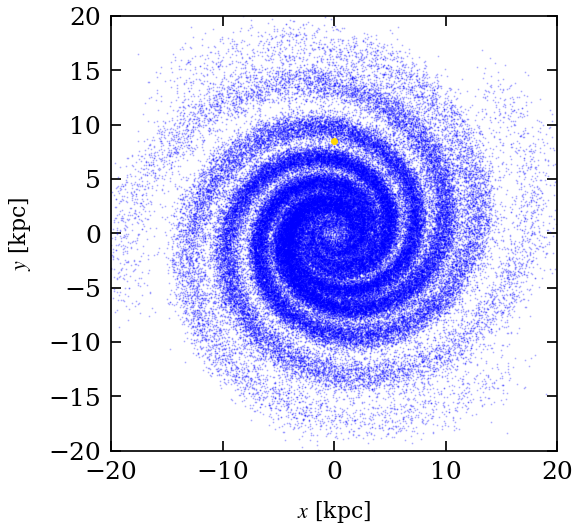

In [5]:
fig, ax = plt.subplots()

ax.plot(
    x,
    y,
    linestyle="None",
    marker="o",
    color="blue",
    markersize=1,
    alpha=0.2,
    rasterized=False
)

ax.plot(0.0, 8.5, marker="o", color="gold", markersize=6)
ax.set_xlabel(r"$x$ [kpc]")
ax.set_ylabel(r"$y$ [kpc]")
ax.set_xlim(-20.0, 20.0)
ax.set_ylim(-20.0, 20.0)

plt.show()

Side view of the galactic plane

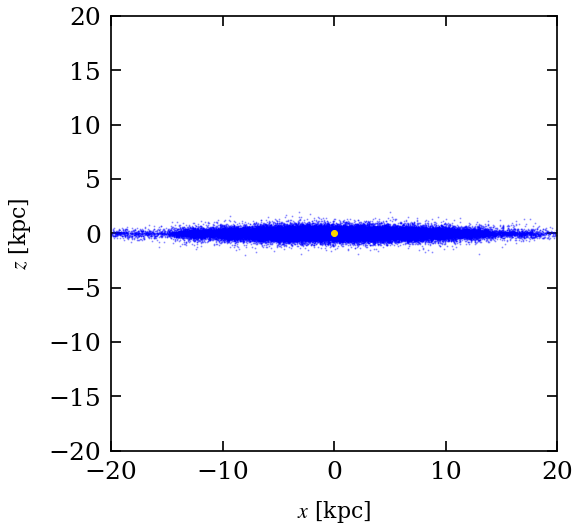

In [6]:
fig, ax = plt.subplots()

ax.plot(
    x,
    z,
    linestyle="None",
    marker="o",
    color="blue",
    markersize=1,
    alpha=0.3,
    rasterized=True,
)

ax.plot(0.0, 0.02, marker="o", color="gold", markersize=6)
ax.set_xlabel(r"$x$ [kpc]")
ax.set_ylabel(r"$z$ [kpc]")
ax.set_xlim(-20.0, 20.0)
ax.set_ylim(-20.0, 20.0)

plt.show()

Histogrammed proper velocity components

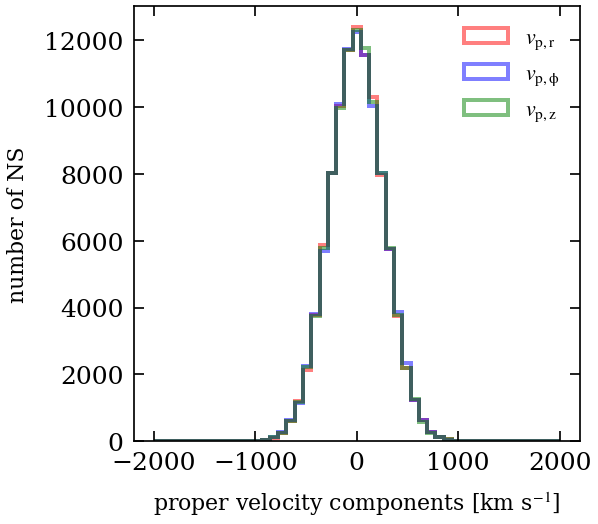

In [7]:
fig, ax = plt.subplots()
x_bins = np.linspace(-2000.,2000.,50)  

ax.hist(
    vk_r,
    bins=x_bins,
    histtype="step",
    edgecolor="red",
    lw=4,
    alpha=0.5,
    label=r"$v_{\rm{p,}r}$",
)
ax.hist(
    vk_phi,
    bins=x_bins,
    histtype="step",
    edgecolor="blue",
    lw=4,
    alpha=0.5,
    label=r"$v_{\rm{p,}\phi}$",
)
ax.hist(
    vk_z,
    bins=x_bins,
    histtype="step",
    edgecolor="green",
    lw=4,
    alpha=0.5,
    label=r"$v_{\rm{p,}z}$",
)
ax.set_xlabel(r"proper velocity components [km s$^{-1}$]")
ax.set_ylabel(r"number of NS")
plt.legend(frameon=False, loc=0)

plt.show()

Orbital (angular) velocity due to galactic potential

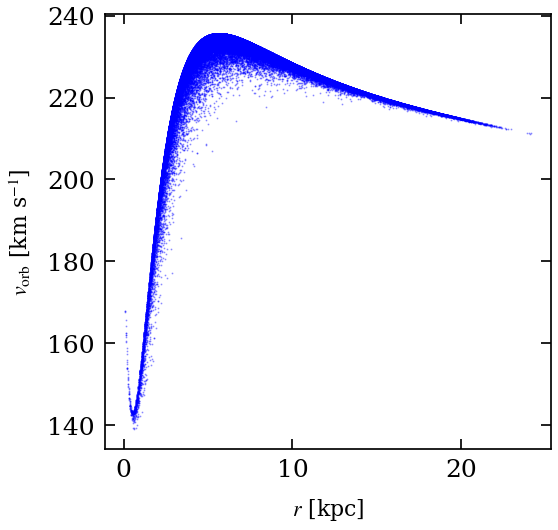

In [8]:
r = np.sqrt(x**2 + y**2)

fig, ax = plt.subplots()

ax.plot(
    r,
    abs(v_orb),
    linestyle="None",
    marker="o",
    color="blue",
    markersize=1,
    alpha=0.3,
    rasterized=True,
)

ax.set_xlabel(r"$r$ [kpc]")
ax.set_ylabel(r"$v_{\rm orb}$ [km s$^{-1}$]")

plt.show()

Histrogramming the pulsars position and comparing to underlying PDF

In [9]:
def pdf_r(r):
    "pdf from the Milky Way stellar surface density (Yusifov & Küçük 2004)"
    A = 37.6  # [stars kpc^-2]
    R1 = 0.55  # +-0.1 [kpc]
    Rsun = 8.5
    a = 1.64  # +-0.11
    b = 4.01  # +-0.24
    rho = (
        A
        * ((r + R1) / (Rsun + R1)) ** a
        * np.exp(-b * ((r - Rsun) / (Rsun + R1)))
    )
    pdf_r = 2 * np.pi * r * rho
    return pdf_r

For normalization purposes, determine the area underneath the theoretical PDF curve:

In [10]:
pdf_area = quad(pdf_r, 0, 100)[0]
print(pdf_area)

24031.290375463075


In [11]:
r_bins = np.linspace(0.0, 30.0, 51)

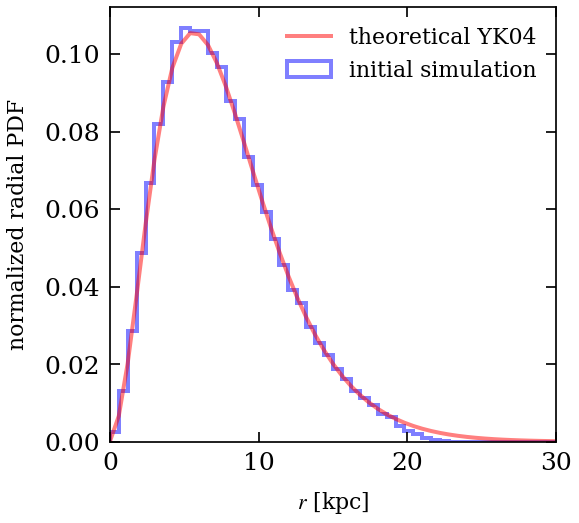

In [12]:
fig, ax = plt.subplots()

ax.hist(
    r,
    bins=r_bins,
    histtype="step",
    edgecolor="blue",
    lw=4,
    alpha=0.5,
    label="initial simulation",
    density=True
)
ax.plot(
    r_bins,
    pdf_r(r_bins)/pdf_area,
    linestyle="-",
    lw=4,
    color="red",
    alpha=0.5,
    label="theoretical YK04",
)
plt.xlabel(r"$r$ [kpc]")
plt.ylabel(r"normalized radial PDF")
plt.xlim(0.0, 30.0)
plt.legend(frameon=False, loc=1)

plt.show()